In [3]:
%pip install plotly -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
# ── Core Libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Display & Formatting ───────────────────────────────────────────────────────
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("giza_weather_clean.csv")

In [7]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1096 entries, 2022-08-01 to 2025-07-31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temp_avg_c       1096 non-null   float64
 1   temp_max_c       1096 non-null   float64
 2   temp_min_c       1096 non-null   float64
 3   precip_mm        1096 non-null   float64
 4   humidity_pct     1096 non-null   float64
 5   windspeed_ms     1096 non-null   float64
 6   cloud_cover_pct  1096 non-null   float64
dtypes: float64(7)
memory usage: 68.5 KB


## Descriptive overview

In [9]:
df.describe()

,temp_avg_c,temp_max_c,temp_min_c,precip_mm,humidity_pct,windspeed_ms,cloud_cover_pct
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,22.584599,30.438659,15.769781,0.336177,52.500338,2.780356,25.270922
std,6.872355,7.621071,5.871208,2.368778,13.369643,0.805054,22.195351
min,8.320000,13.750000,2.650000,0.000000,15.880000,0.750000,0.280000
25%,15.957500,23.317500,10.410000,0.000000,43.107500,2.230000,8.432500
50%,22.865000,31.030000,15.870000,0.000000,51.220000,2.780000,18.835000
75%,29.332500,37.842500,21.327500,0.010000,62.592500,3.300000,34.730000
max,35.050000,45.490000,27.510000,42.540000,84.600000,5.700000,99.890000


In [20]:
# Making sure No missing day in our range 
time_range = pd.date_range(start="2022-08-01",end="2025-07-31",freq="D")
condition = (time_range == df.index).all()
print(condition)

True


In [10]:
df.tail(4)

,temp_avg_c,temp_max_c,temp_min_c,precip_mm,humidity_pct,windspeed_ms,cloud_cover_pct
date,,,,,,,
2025-07-28,32.88,41.39,24.69,0.0,34.17,2.94,17.90
2025-07-29,31.41,40.13,23.98,0.0,47.79,3.45,16.12
2025-07-30,30.00,38.03,22.83,0.0,45.85,3.01,12.74
2025-07-31,29.49,37.00,23.09,0.0,50.55,3.48,24.41


In [13]:
df.index

DatetimeIndex(['2022-08-01', '2022-08-02', '2022-08-03', '2022-08-04',
               '2022-08-05', '2022-08-06', '2022-08-07', '2022-08-08',
               '2022-08-09', '2022-08-10',
               ...
               '2025-07-22', '2025-07-23', '2025-07-24', '2025-07-25',
               '2025-07-26', '2025-07-27', '2025-07-28', '2025-07-29',
               '2025-07-30', '2025-07-31'],
              dtype='datetime64[us]', name='date', length=1096, freq=None)

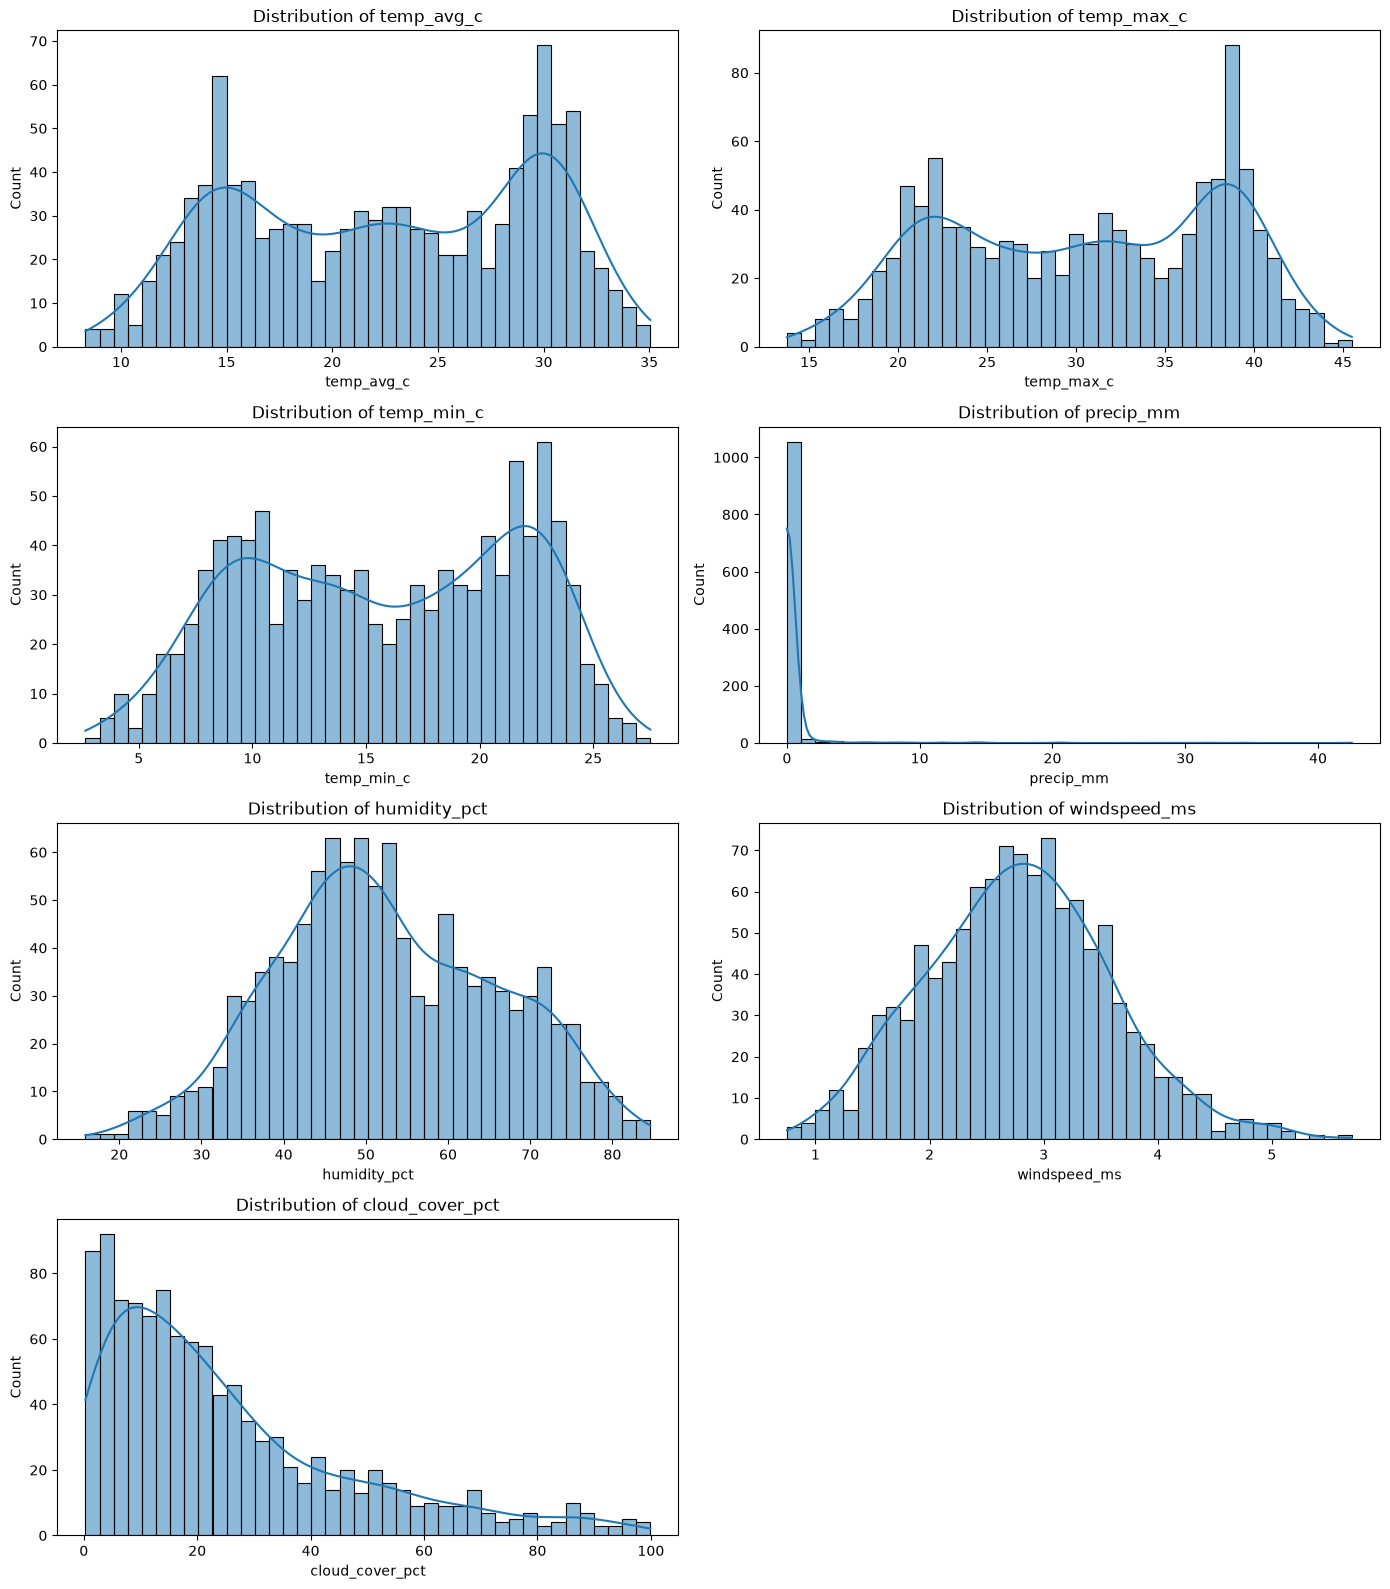

In [18]:
cols = ['temp_avg_c', 'temp_max_c', 'temp_min_c', 'precip_mm',
        'humidity_pct', 'windspeed_ms', 'cloud_cover_pct']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

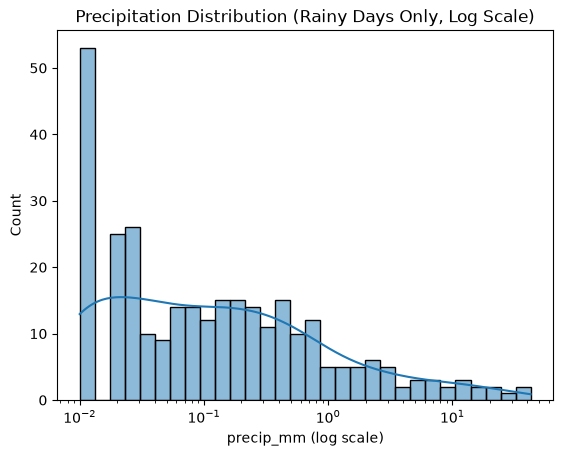

In [21]:
sns.histplot(rainy_days, kde=True, bins=30, log_scale=True)
plt.title('Precipitation Distribution (Rainy Days Only, Log Scale)')
plt.xlabel('precip_mm (log scale)')
plt.show()

In [20]:
(df['precip_mm'] == 0).mean() * 100   # % of days with zero rain

np.float64(72.53649635036497)

## Temporal patterns


### temp accros years 

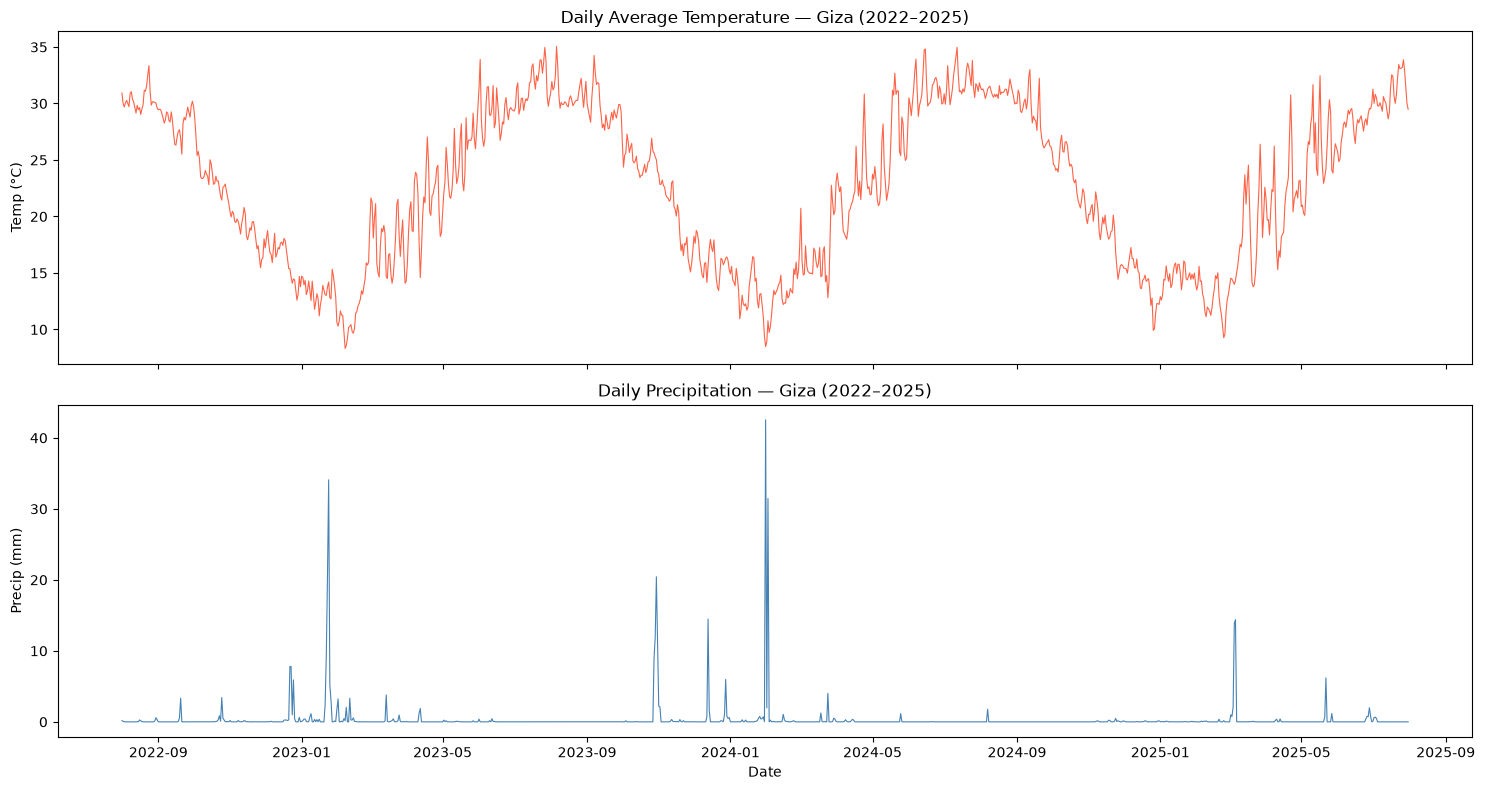

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df.index, df['temp_avg_c'], color='tomato', linewidth=0.8)
axes[0].set_title('Daily Average Temperature — Giza (2022–2025)')
axes[0].set_ylabel('Temp (°C)')

axes[1].plot(df.index, df['precip_mm'], color='steelblue', linewidth=0.8)
axes[1].set_title('Daily Precipitation — Giza (2022–2025)')
axes[1].set_ylabel('Precip (mm)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

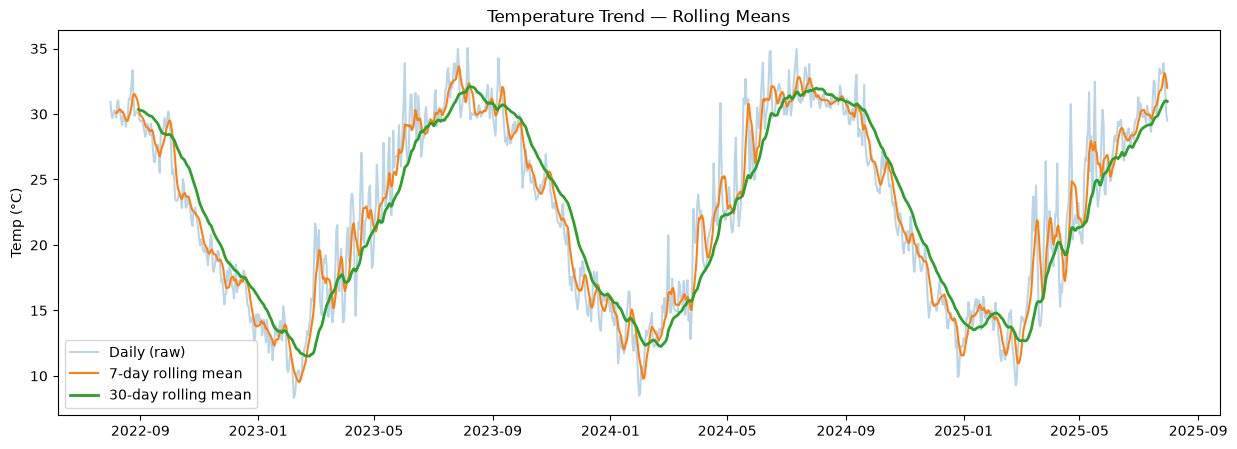

In [22]:
df['temp_roll7'] = df['temp_avg_c'].rolling(window=7).mean()
df['temp_roll30'] = df['temp_avg_c'].rolling(window=30).mean()

plt.figure(figsize=(15, 5))
plt.plot(df.index, df['temp_avg_c'], alpha=0.3, label='Daily (raw)')
plt.plot(df.index, df['temp_roll7'], label='7-day rolling mean')
plt.plot(df.index, df['temp_roll30'], label='30-day rolling mean', linewidth=2)
plt.title('Temperature Trend — Rolling Means')
plt.ylabel('Temp (°C)')
plt.legend()
plt.show()

### seasonality 

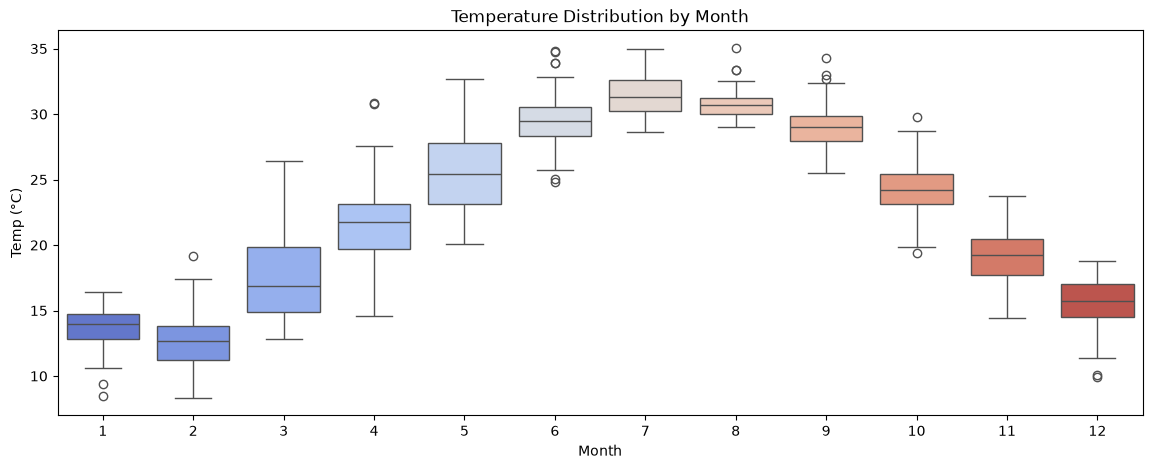

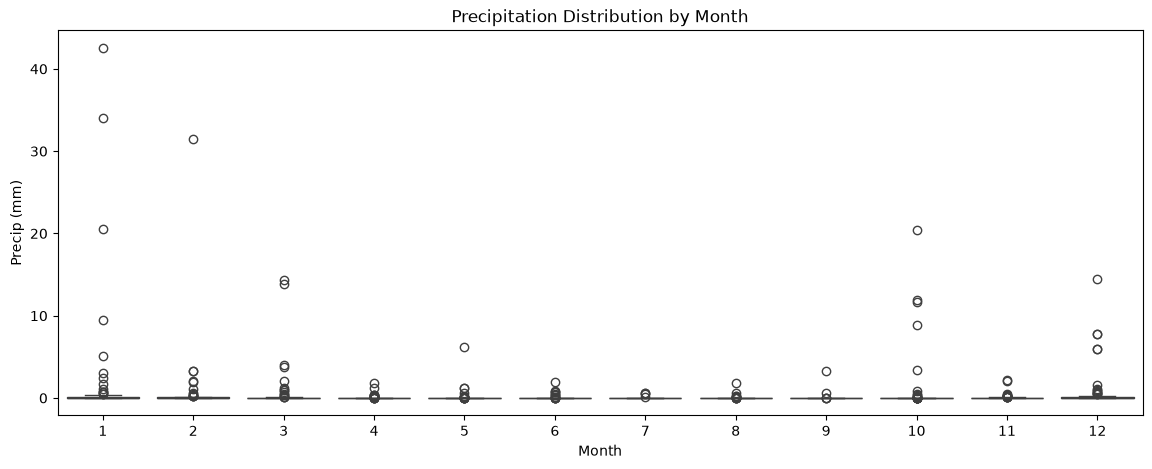

In [23]:
df['month'] = df.index.month

plt.figure(figsize=(14, 5))
sns.boxplot(x='month', y='temp_avg_c', data=df, palette='coolwarm')
plt.title('Temperature Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Temp (°C)')
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(x='month', y='precip_mm', data=df)
plt.title('Precipitation Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Precip (mm)')
plt.show()

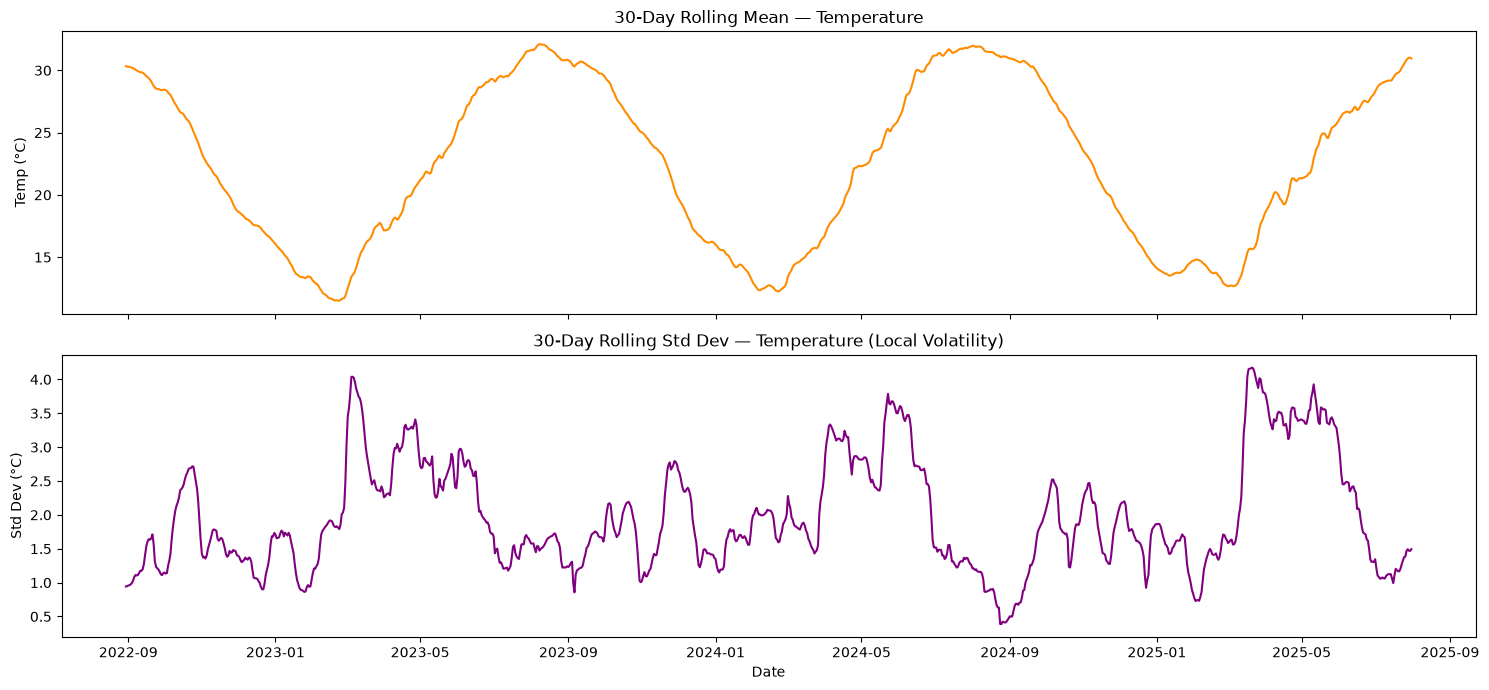

In [24]:
df['temp_roll_std30'] = df['temp_avg_c'].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(df.index, df['temp_roll30'], color='darkorange')
axes[0].set_title('30-Day Rolling Mean — Temperature')
axes[0].set_ylabel('Temp (°C)')

axes[1].plot(df.index, df['temp_roll_std30'], color='purple')
axes[1].set_title('30-Day Rolling Std Dev — Temperature (Local Volatility)')
axes[1].set_ylabel('Std Dev (°C)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Decomposition

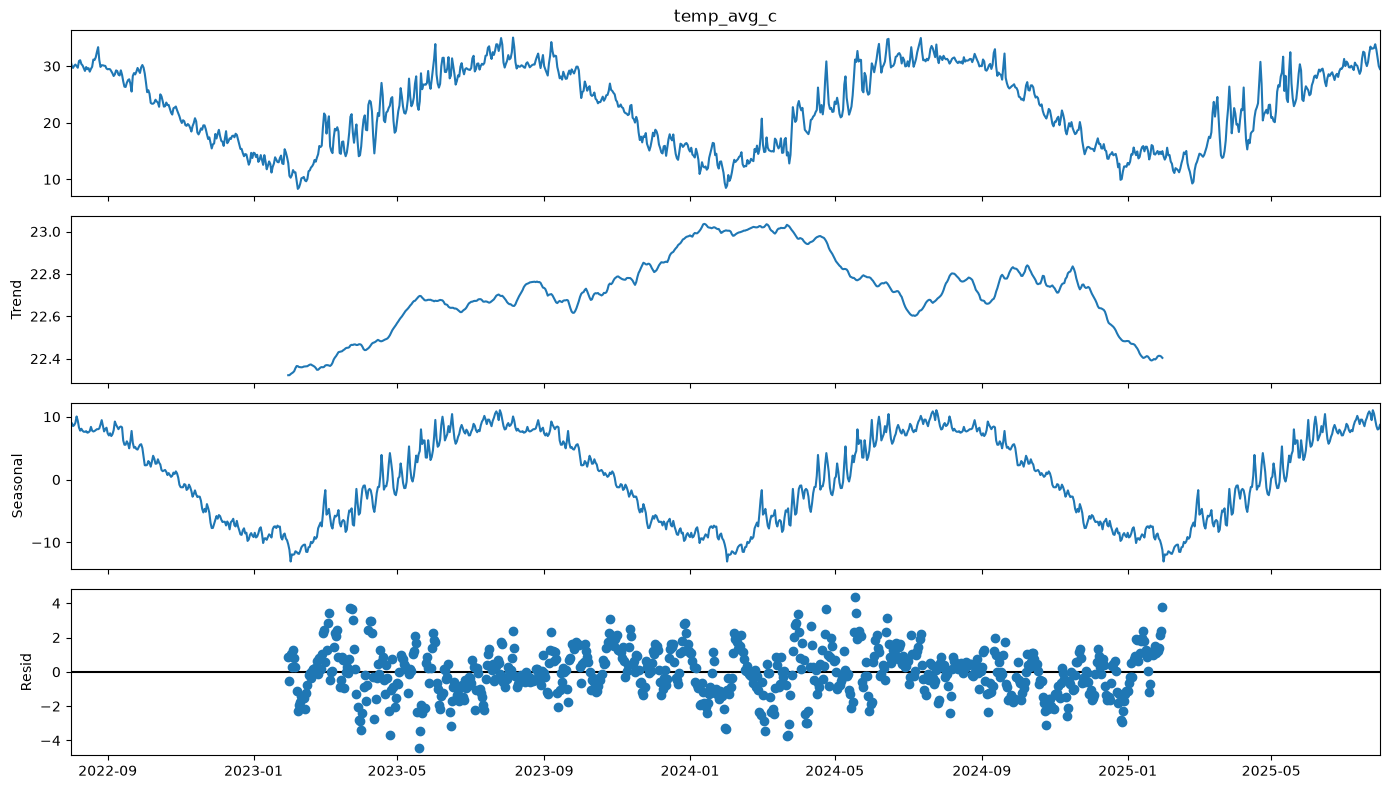

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period=365 because your data is daily and the seasonal cycle is yearly
result = seasonal_decompose(df['temp_avg_c'], model='additive', period=365)

fig = result.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

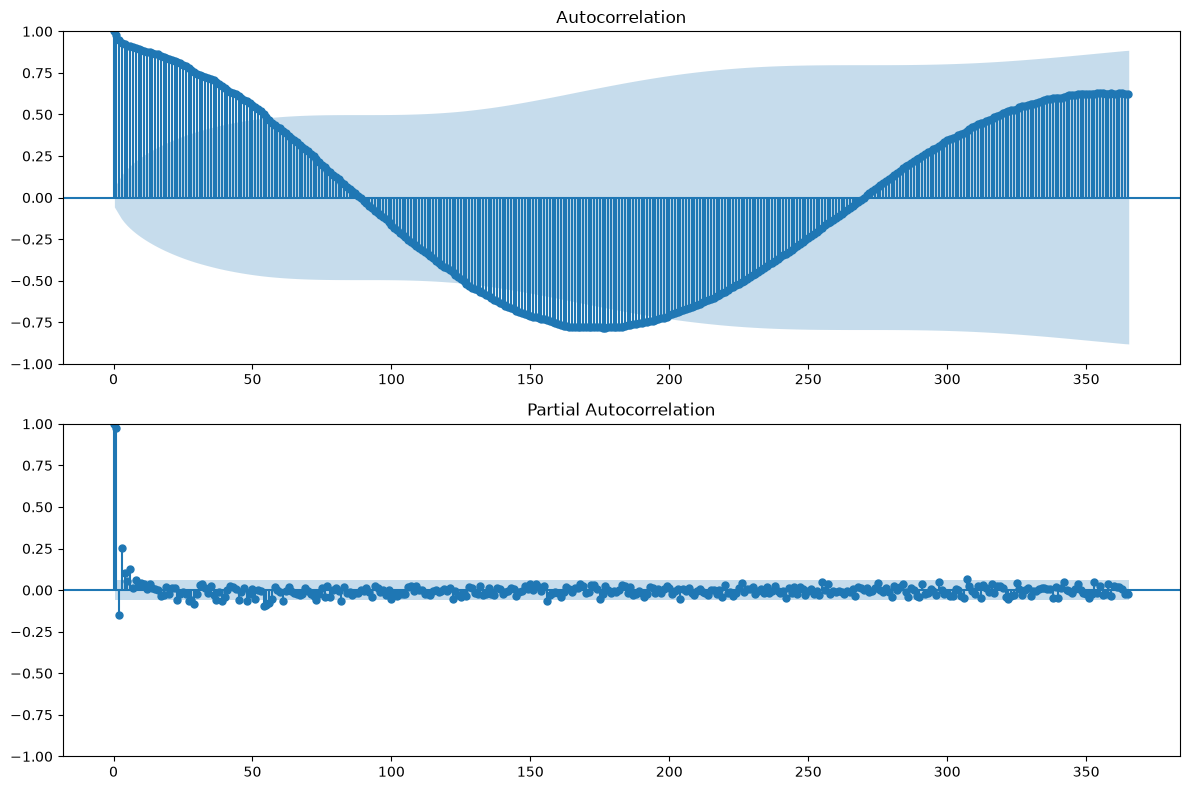

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['temp_avg_c'], lags=365, ax=axes[0])
plot_pacf(df['temp_avg_c'], lags=365, ax=axes[1])
plt.tight_layout()
plt.show()

In [27]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['temp_avg_c'].dropna())

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -1.9180
p-value: 0.3236
Critical Values:
   1%: -3.4364
   5%: -2.8642
   10%: -2.5682


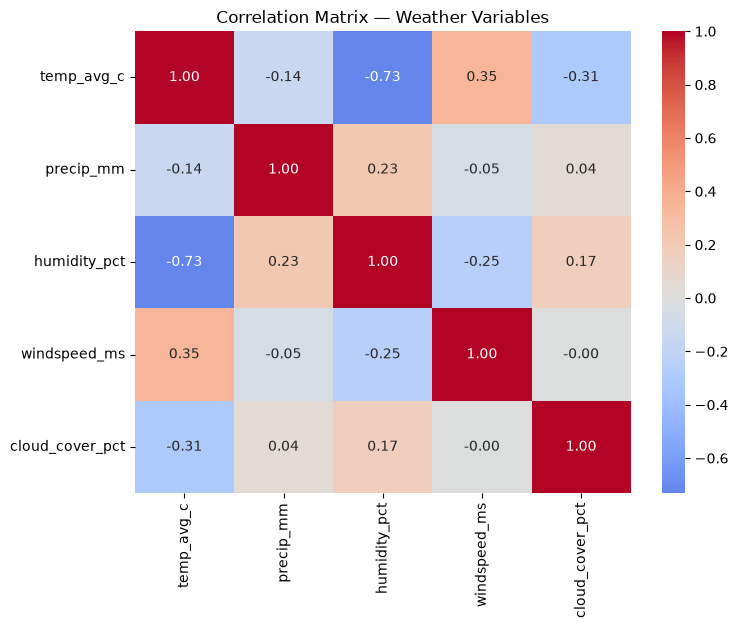

In [31]:
corr_cols = ['temp_avg_c', 'precip_mm', 'humidity_pct', 'windspeed_ms', 'cloud_cover_pct']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix — Weather Variables')
plt.show()

## 1) which month is likely the hottest ?

In [32]:
hottest_month = df.groupby('month')['temp_avg_c'].mean().idxmax()
hottest_val = df.groupby('month')['temp_avg_c'].mean().max()
print(f"Hottest month: {hottest_month} (avg {hottest_val:.2f}°C)")

df.groupby('month')['temp_avg_c'].mean().sort_values(ascending=False)

Hottest month: 7 (avg 31.46°C)


month
7     31.456237
8     30.725591
6     29.534222
9     28.967444
5     25.548280
10    24.219677
4     21.560444
11    19.121000
3     17.481398
12    15.537849
1     13.728495
2     12.557294
Name: temp_avg_c, dtype: float64

## Rainest month 

In [37]:
rainiest_month = df.groupby('month')['precip_mm'].sum().idxmax()
rainiest_val = df.groupby('month')['precip_mm'].sum().max()
print(f"Rainiest month: {rainiest_month} (total {rainiest_val:.2f}mm across all years)")

df.groupby('month')['precip_mm'].sum().sort_values(ascending=False)

Rainiest month: 1 (total 127.42mm across all years)


month
1     127.42
10     58.77
12     51.77
2      47.21
3      44.65
5      10.02
11      8.06
6       5.89
4       5.33
9       3.97
8       3.52
7       1.84
Name: precip_mm, dtype: float64

## most cloudy month and stronger winds one

In [38]:
cloudiest_month = df.groupby('month')['cloud_cover_pct'].mean().idxmax()
cloudiest_val = df.groupby('month')['cloud_cover_pct'].mean().max()
print(f"Cloudiest month: {cloudiest_month} (avg {cloudiest_val:.2f}% cloud cover)")

df.groupby('month')['cloud_cover_pct'].mean().sort_values(ascending=False)

Cloudiest month: 2 (avg 40.51% cloud cover)


month
2     40.506824
4     35.318222
1     33.257097
3     33.057312
5     30.090753
12    28.954086
11    25.174111
8     18.553871
10    18.267312
6     17.429111
7     12.866559
9     10.683889
Name: cloud_cover_pct, dtype: float64

In [39]:
windiest_month = df.groupby('month')['windspeed_ms'].mean().idxmax()
windiest_val = df.groupby('month')['windspeed_ms'].mean().max()
print(f"Windiest month: {windiest_month} (avg {windiest_val:.2f} m/s)")

df.groupby('month')['windspeed_ms'].mean().sort_values(ascending=False)

Windiest month: 6 (avg 3.37 m/s)


month
6     3.371111
5     3.320108
8     3.034086
7     2.985484
4     2.982111
9     2.966000
10    2.796774
3     2.565914
2     2.412235
12    2.382581
11    2.359444
1     2.174731
Name: windspeed_ms, dtype: float64

### seems that winter months are more cloudy and summer ones have stroger winds 

## Days per year with max temp > 25°C vs ≤ 25°C

      days_<=25C  days_>25C
year                       
2022          34        119
2023         112        253
2024         120        246
2025          77        135


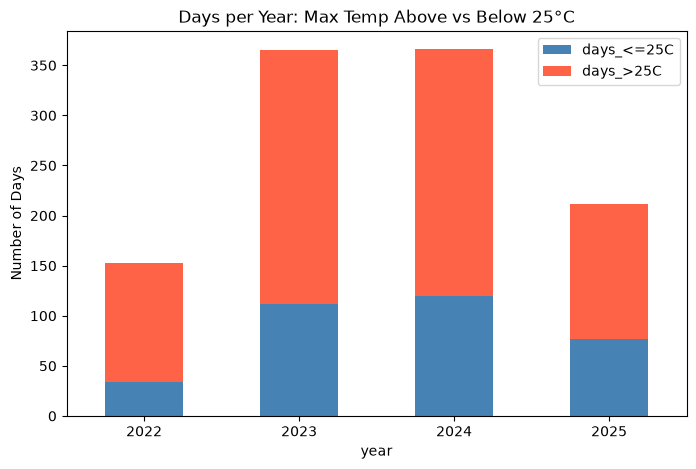

In [40]:
df['year'] = df.index.year
df['hot_day'] = df['temp_max_c'] > 25

days_per_year = df.groupby(['year', 'hot_day']).size().unstack(fill_value=0)
days_per_year.columns = ['days_<=25C', 'days_>25C']
print(days_per_year)

# Quick visual
days_per_year.plot(kind='bar', stacked=True, figsize=(8,5), color=['steelblue','tomato'])
plt.title('Days per Year: Max Temp Above vs Below 25°C')
plt.ylabel('Number of Days')
plt.xticks(rotation=0)
plt.show()

In [42]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1096 entries, 2022-08-01 to 2025-07-31
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temp_avg_c       1096 non-null   float64
 1   temp_max_c       1096 non-null   float64
 2   temp_min_c       1096 non-null   float64
 3   precip_mm        1096 non-null   float64
 4   humidity_pct     1096 non-null   float64
 5   windspeed_ms     1096 non-null   float64
 6   cloud_cover_pct  1096 non-null   float64
 7   temp_roll7       1090 non-null   float64
 8   temp_roll30      1067 non-null   float64
 9   month            1096 non-null   int32  
 10  temp_roll_std30  1067 non-null   float64
 11  year             1096 non-null   int32  
 12  hot_day          1096 non-null   bool   
dtypes: bool(1), float64(10), int32(2)
memory usage: 103.8 KB


In [43]:
cols_to_drop = ['temp_roll7', 'temp_roll30', 'temp_roll_std30', 'month', 'year', 'hot_day']

df = df.drop(columns=cols_to_drop)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1096 entries, 2022-08-01 to 2025-07-31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temp_avg_c       1096 non-null   float64
 1   temp_max_c       1096 non-null   float64
 2   temp_min_c       1096 non-null   float64
 3   precip_mm        1096 non-null   float64
 4   humidity_pct     1096 non-null   float64
 5   windspeed_ms     1096 non-null   float64
 6   cloud_cover_pct  1096 non-null   float64
dtypes: float64(7)
memory usage: 68.5 KB
